In [4]:
# ==============================================================
# Section 1: import libraries
# ==============================================================

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from scipy.sparse import diags
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse.linalg import splu
from numba import njit

mpl.rcParams['animation.embed_limit'] = 100  # MB

In [73]:
# =============================================================
# Section 2: physical constants
# =============================================================

c = 299792458.0                      # m s^-1
planck = 6.62607015e-34             # J s
reduced_planck = planck / (2.0 * np.pi)
eps0 = 8.854187818814e-12           # F m^-1
mass = 9.109383713928e-31           # kg
elem_charge = 1.602176634e-19       # C
kB = 1.380649e-23
p0 = 10**5; T0 = 273.15

In [74]:
# =============================================================
# Section 3: beam parameters
# =============================================================

lam = 775e-9
wavenumber = 2.0 * np.pi / lam
omega = 2.0 * np.pi * c / lam
w = 0.7e-3
zR = wavenumber * w**2 / 2.0
tp = 85e-15
ddot_k = 2.0 * (1e-15)**2 * (1e-2)**(-1)


In [75]:
# =============================================================
# Section 4: material parameters
# =============================================================

n2 = 5.57e-23
Pcr = lam**2 / (2.0 * np.pi * n2)
Eg = 11.0 * 1.6e-19
coeff_keldysh = int(np.ceil(Eg / (reduced_planck * omega)))
beta_keldysh = 6.5e-104
tau = 3.5e-13
a = 5e-13
sigma = (
    wavenumber * elem_charge**2 * tau
    / (omega * mass * eps0)
    / (1.0 + omega**2 * tau**2)
)
Pin = 6.5 * Pcr
rho0 = p0 / (kB * T0)

In [ ]:
# =============================================================
# Section 5: define the space mesh
# =============================================================

rmin = 0
rmax = 5 * w
Nr = 1_000
DeltaR = (rmax - rmin) / (Nr + 1)
r_vector = np.linspace(rmin, rmax, Nr + 2)

tmin = -2.5 * tp
tmax = 2.5 * tp
Nt = 100
DeltaT = (tmax - tmin) / (Nt + 1)
t_vector = np.linspace(tmin, tmax, Nt + 2)

zmin = 0.0
zmax = 4
mag = 100
Nz = 1_000
DeltaZ = (zmax - zmin) / (mag * (Nz + 1))
z_vector = np.linspace(zmin, zmax, mag * (Nz + 1) + 1)
z_diag = np.linspace(zmin, zmax, mag)

radial_matrix, time_matrix = np.meshgrid(r_vector, t_vector, indexing='ij')

In [82]:
# =============================================================
# Section 6: initialize the matrices
# =============================================================

delta = DeltaZ / (4.0 * wavenumber * DeltaR**2)
d = -ddot_k * DeltaZ / (4.0 * DeltaT**2)

main_plus_delta = np.array(
    [1.0 - 4j * delta] + [1.0 - 2j * delta for _ in range(1, Nr + 1)] + [0.0],
    dtype=np.complex128
)
upper_plus_delta = np.array(
    [4j * delta] + [1j * delta * (1.0 + 0.5 / k) for k in range(1, Nr + 1)],
    dtype=np.complex128
)
lower_plus_delta = np.array(
    [1j * delta * (1.0 - 0.5 / k) for k in range(1, Nr + 1)] + [0.0],
    dtype=np.complex128
)
L_plus_delta = diags(
    [lower_plus_delta, main_plus_delta, upper_plus_delta],
    offsets=[-1, 0, 1],
    format='csc',
    dtype=np.complex128
)

main_minus_delta = np.array(
    [1.0 + 4j * delta] + [1.0 + 2j * delta for _ in range(1, Nr + 1)] + [1.0],
    dtype=np.complex128
)
upper_minus_delta = np.array(
    [-4j * delta] + [-1j * delta * (1.0 + 0.5 / k) for k in range(1, Nr + 1)],
    dtype=np.complex128
)
lower_minus_delta = np.array(
    [-1j * delta * (1.0 - 0.5 / k) for k in range(1, Nr + 1)] + [0.0],
    dtype=np.complex128
)
L_minus_delta = diags(
    [lower_minus_delta, main_minus_delta, upper_minus_delta],
    offsets=[-1, 0, 1],
    format='csc',
    dtype=np.complex128
)

main_plus_d = np.array(
    [1.0 - 2j * d for _ in range(Nt + 1)] + [0.0],
    dtype=np.complex128
)
upper_plus_d = np.array(
    [1j * d for _ in range(Nt)] + [0.0],
    dtype=np.complex128
)
lower_plus_d = np.array(
    [2j * d] + [1j * d for _ in range(2, Nt + 2)],
    dtype=np.complex128
)
L_plus_d = diags(
    [lower_plus_d, main_plus_d, upper_plus_d],
    offsets=[-1, 0, 1],
    format='csc',
    dtype=np.complex128
)

main_minus_d = np.array(
    [1.0 + 2j * d for _ in range(Nt + 1)] + [1.0],
    dtype=np.complex128
)
upper_minus_d = np.array(
    [-1j * d for _ in range(Nt)] + [0.0],
    dtype=np.complex128
)
lower_minus_d = np.array(
    [-2j * d] + [-1j * d for _ in range(2, Nt + 2)],
    dtype=np.complex128
)
L_minus_d = diags(
    [lower_minus_d, main_minus_d, upper_minus_d],
    offsets=[-1, 0, 1],
    format='csc',
    dtype=np.complex128
)

M1 = splu(L_minus_delta)
M2= L_plus_delta.T
lower_plus_delta_transpose = np.diag(M2.toarray(), k=-1)
main_plus_delta_transpose = np.diag(M2.toarray(), k=0)
upper_plus_delta_transpose = np.diag(M2.toarray(), k=1)
A_t = np.ascontiguousarray(L_minus_d.T.toarray())
lu_t, piv_t = lu_factor(A_t)



@njit(cache=True, fastmath=True)
def right_multiply_tridiag(X, lower, main, upper):
    """
    X is a 2d array of size len_y (rows) x len_x (columns)
    main is a row vector of len_x; lower and upper are row vectors of len_x - 1
    """
    len_y, len_x = X.shape
    Y = np.zeros((len_y, len_x), dtype=np.complex128)
    Y[:, 0] = X[:, 0] * main[0] + X[:, 1] * lower[0]
    Y[:, len_x - 1] = X[:, len_x - 2] * upper[len_x - 2] + X[:, len_x - 1] * main[len_x - 1]
    for j in range(1, len_x - 1):
        Y[:, j] = X[:, j - 1] * upper[j - 1] + X[:, j] * main[j] + X[:, j + 1] * lower[j]
    
    return Y

In [83]:
# =============================================================
# Section 7: initialize the envelope, rho, and diagnostic intensity
# =============================================================

intensity_diag = np.zeros(mag, dtype=np.float64)

amp0 = np.sqrt(2.0 * Pin / (np.pi * w**2))
E = (
    amp0
    * np.exp(-radial_matrix**2 / w**2 - time_matrix**2 / tp**2)
).astype(np.complex128)

rho_k = np.zeros((Nr + 2, Nt + 2), dtype=np.float64)
nonlinear_prev = np.zeros((Nr + 2, Nt + 2), dtype=np.complex128)

In [84]:
# =============================================================
# Section 8: fast rho update
# =============================================================

@njit(cache=True, fastmath=True)
def update_rho_slice_from_I(rho_k, I_k):
    """
    rho_k is the electron density and is forced to remain >= 0.
    I_k is the intensity |E|^2.
    """
    avalanche_pref = sigma * DeltaT / Eg
    mpa_pref = beta_keldysh * DeltaT / (coeff_keldysh * reduced_planck * omega)
    recomb_pref = a * DeltaT

    # boundary conditions
    for l in range(Nt + 2):
        rho_k[Nr + 1, l] = 0.0
    for j in range(Nr + 2):
        rho_k[j, Nt + 1] = 0.0

    # initial time condition
    for j in range(Nr + 2):
        rho_k[j, 0] = 0.0

    for j in range(Nr + 1):
        # first time step
        balance = rho_k[j, 0]
        I = I_k[j, 0]
        Ipow = I ** coeff_keldysh

        val = (
            balance
            + avalanche_pref * balance * I
            + mpa_pref * Ipow
            - recomb_pref * balance * balance
        )
        rho_k[j, 1] = val if val >= 0.0 else 0.0

        # Adams-Bashforth-like update
        for l in range(1, Nt):
            balance = rho_k[j, l]
            back_balance = rho_k[j, l - 1]

            I = I_k[j, l]
            back_I = I_k[j, l - 1]

            Ipow = I ** coeff_keldysh
            back_Ipow = back_I ** coeff_keldysh

            val = (
                balance
                + avalanche_pref * (1.5 * balance * I - 0.5 * back_balance * back_I)
                + mpa_pref * (1.5 * Ipow - 0.5 * back_Ipow)
                - recomb_pref * (1.5 * balance * balance - 0.5 * back_balance * back_balance)
            )

            rho_k[j, l + 1] = val if val >= 0.0 else 0.0


In [ ]:
# ================================================================
# Section 9: propagate the electric field
# ================================================================


gamma = -0.5 * sigma * (1.0 + 1j * omega * tau)
mpa_field_pref = -0.5 * beta_keldysh
kerr_pref = 1j * wavenumber * n2

first_step = True

for ind1 in range(mag):
    I = E.real * E.real + E.imag * E.imag
    intensity_diag[ind1] = np.nanmax(I)

    for k in range(Nz + 1):
        I = E.real * E.real + E.imag * E.imag
        update_rho_slice_from_I(rho_k, I)

        Ipow = I ** (coeff_keldysh - 1)
        nonlinear_current = (
            mpa_field_pref * Ipow * E
            + kerr_pref * I * E
            + gamma * rho_k * E
        )

        if first_step:
            nonlinear = nonlinear_current
            first_step = False
        else:
            nonlinear = 1.5 * nonlinear_current - 0.5 * nonlinear_prev

        E = E + DeltaZ * nonlinear
        RHS = right_multiply_tridiag(E, lower_plus_d, main_plus_d, upper_plus_d)
        intermediary_step = M1.solve(RHS).T
        RHS = right_multiply_tridiag(intermediary_step, lower_plus_delta_transpose, main_plus_delta_transpose, upper_plus_delta_transpose)
        E = lu_solve((lu_t, piv_t), RHS).T
        
        nonlinear_prev[:, :] = nonlinear_current


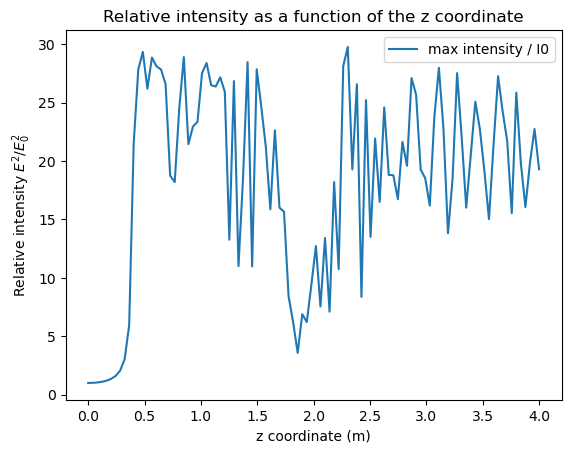

In [71]:
# ================================================================
# Section 11: plot ratio of max intensity to I0
# ================================================================

M = intensity_diag / intensity_diag[0]

fig2, ax2 = plt.subplots()
ax2.plot(z_diag[z_diag <= 4], M[z_diag <= 4], label='max intensity / I0')
ax2.set_xlabel('z coordinate (m)')
ax2.set_ylabel(r'Relative intensity $E^2/E_0^2$')
ax2.set_title('Relative intensity as a function of the z coordinate')
ax2.legend()
plt.show()